In [1]:
# Initialize libraries
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arrow

os.chdir('/home/kaseng/warehouse/data/')

### Scenario 1: Target and Obstacle Overlap

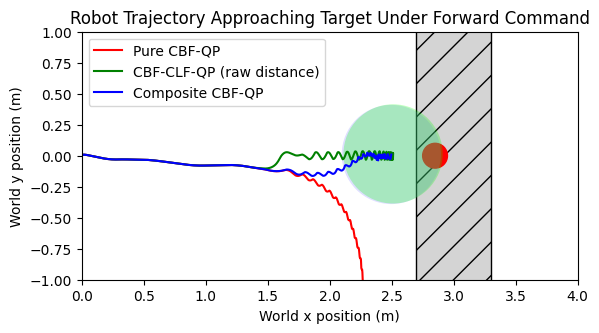

In [2]:
# Trajectory plots for obstacle

data_threshold = 10000

composite_3 = np.load("./composite_pos_3.npy")
separated_1 = np.load("./separated_1.npy")
pure = np.load("./pure_trial_1.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.85, 0.0), radius=0.1, edgecolor="red", facecolor="red")
circle_composite = Circle((composite_3[data_threshold-1, :2]), radius=0.4, facecolor=(0.5,0.5,1.0,0.25))
circle_separate_1 = Circle((separated_1[data_threshold-1,:2]), radius=0.4, facecolor=(0, 1, 0, 0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_composite)
ax.add_patch(circle_separate_1)

ax.plot(pure[:data_threshold,0], pure[:data_threshold,1], color="r", label="Pure CBF-QP")
ax.plot(separated_1[:data_threshold,0], separated_1[:data_threshold,1], color="g", label="CBF-CLF-QP (raw distance)")
ax.plot(composite_3[:data_threshold,0], composite_3[:data_threshold,1], color="b", label="Composite CBF-QP")

ax.set_xlim(0, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Robot Trajectory Approaching Target Under Forward Command')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend()
plt.show()

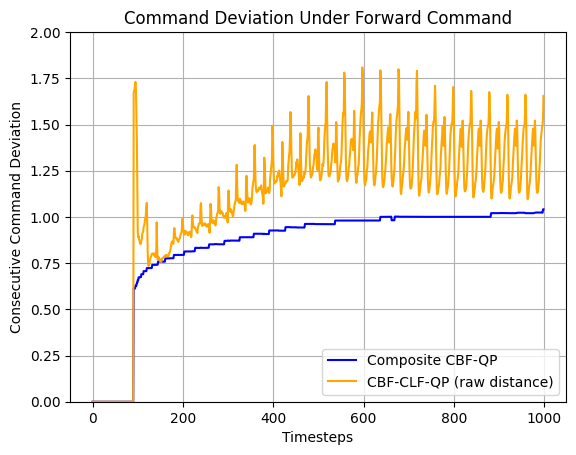

In [3]:
# Consecutive command error (squared error)

composite_cmds = np.load("./composite_cmds_3.npy")
separated_cmds = np.load("./separated_cmds.npy")

def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(composite_cmds,axis=0)), command_change(composite_cmds), color="b", label="Composite CBF-QP")
ax.plot(range(np.size(separated_cmds,axis=0)), command_change(separated_cmds), color=(1.0,0.65,0), label="CBF-CLF-QP (raw distance)")
ax.set_ylim(0, 2.0)
plt.title('Command Deviation Under Forward Command')
plt.xlabel("Timesteps")
plt.ylabel("Consecutive Command Deviation")
plt.grid(True)
plt.legend()
plt.show()


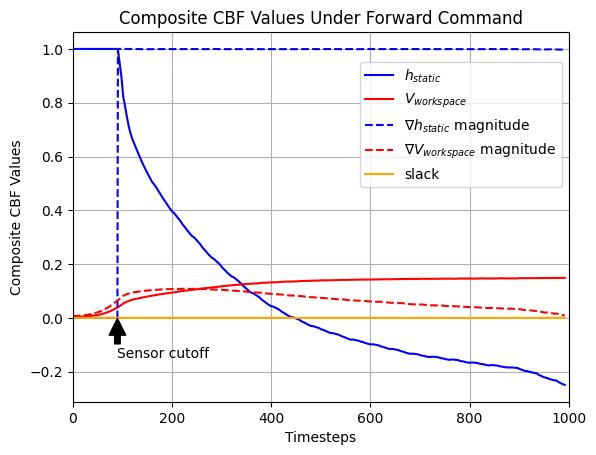

In [4]:
# CBF values
# [cbf.h_static_obs, cbf.h_workspace, np.linalg.norm(cbf.grad_h_static_obs), np.linalg.norm(cbf.grad_h_workspace), cbf.moving_slack]
composite_values = np.load("./composite_values_3.npy")[0]
fig, ax = plt.subplots()

h_static = composite_values[:, 0]
h_workspace = composite_values[:, 1]
h_grad_static = composite_values[:, 2]
h_grad_workspace = composite_values[:, 3]
h_slack = composite_values[:, 4]

ax.plot(range(np.size(composite_values,axis=0)), h_static, color="b", label=r'$h_{static}$')
ax.plot(range(np.size(composite_values,axis=0)), h_workspace, color="r", label=r'$V_{workspace}$')
ax.plot(range(np.size(composite_values,axis=0)), h_grad_static, color="b", label=r'$\nabla h_{static}$ magnitude', ls="--")
ax.plot(range(np.size(composite_values,axis=0)), h_grad_workspace, color="r", label=r'$\nabla V_{workspace}$ magnitude', ls="--")
ax.plot(range(np.size(composite_values,axis=0)), h_slack, color=(1.0,0.65,0), label="slack")
plt.title('Composite CBF Values Under Forward Command')
plt.xlabel("Timesteps")
plt.ylabel("Composite CBF Values")
ax.set_xlim(0, 1000)
plt.grid(True)
plt.legend(loc='right', bbox_to_anchor=(1.0, 0.75))
# plt.text(, -0.1, 'sensor cutoff', fontsize=12)
plt.annotate('Sensor cutoff', xy=(90, 0), xytext=(90, -0.15),
             arrowprops=dict(facecolor='black', shrink=0.02))
plt.show()

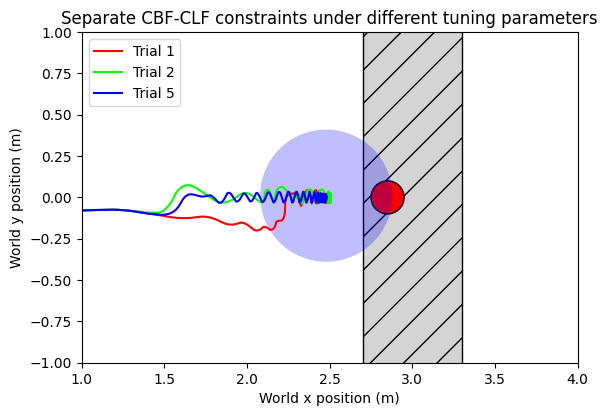

In [5]:
# Trajectory plots for tuning alpha and gamma for separate CBF_CLF

data_threshold = 10000

# Load data
separated_1 = np.load("./separated_pos_1.npy")
separated_2 = np.load("./separated_pos_2.npy")
separated_4 = np.load("./separated_pos_4.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.85, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_separated_1 = Circle((separated_1[data_threshold-1,:2]), radius=0.4, facecolor=(0,0,1.0,0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_separated_1)

ax.plot(separated_2[:data_threshold,0], separated_2[:data_threshold,1], color=(1.0,0,0), label="Trial 1")
ax.plot(separated_4[:data_threshold,0], separated_4[:data_threshold,1], color=(0,1,0), label="Trial 2")
ax.plot(separated_1[:data_threshold,0], separated_1[:data_threshold,1], color=(0,0,1.0), label="Trial 5")
ax.set_xlim(1, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Separate CBF-CLF constraints under different tuning parameters')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend(loc="upper left")
plt.show()

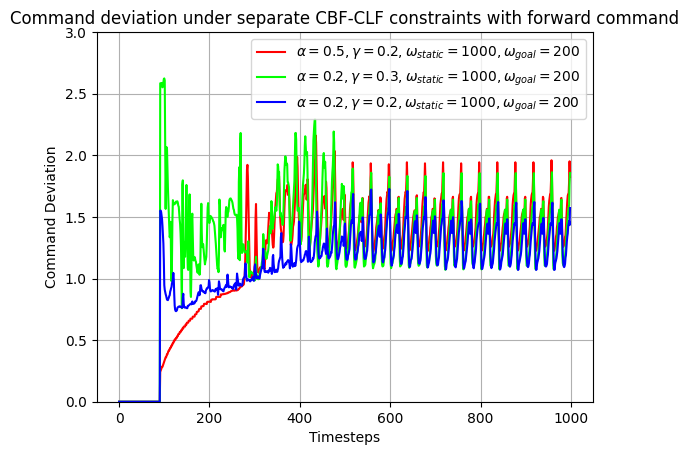

Consecutive command deviation 2
0.00960850850850851
0.013335586058858115
Consecutive command deviation 4
0.024653653653653653
0.11530158585147053
Consecutive command deviation 1
0.008777077077077077
0.049500808024315376


In [6]:
# Consecutive command error for tuning alpha and gamma for separate CBF_CLF

# Load data
separated_cmds_1 = np.load("./separated_cmds_1.npy")
separated_cmds_2 = np.load("./separated_cmds_2.npy")
separated_cmds_4 = np.load("./separated_cmds_4.npy")

def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(separated_cmds_2,axis=0)), command_change(separated_cmds_2), color=(1.0,0,0), label=r"$\alpha=0.5,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=200$")
ax.plot(range(np.size(separated_cmds_4,axis=0)), command_change(separated_cmds_4), color=(0,1,0), label=r"$\alpha=0.2,\gamma=0.3, \omega_{static}=1000, \omega_{goal}=200$")
ax.plot(range(np.size(separated_cmds_1,axis=0)), command_change(separated_cmds_1), color=(0,0,1.0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=200$")
ax.set_ylim(0, 3.0)
plt.title('Command deviation under separate CBF-CLF constraints with forward command')
plt.xlabel("Timesteps")
plt.ylabel("Command Deviation")
plt.grid(True)
plt.legend()
plt.show()

def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

separated_change_2 = consecutive_change(separated_cmds_2)
print("Consecutive command deviation 2")
print(np.mean(separated_change_2))
print(np.std(separated_change_2))
separated_change_4 = consecutive_change(separated_cmds_4)
print("Consecutive command deviation 4")
print(np.mean(separated_change_4))
print(np.std(separated_change_4))
separated_change_1 = consecutive_change(separated_cmds_1)
print("Consecutive command deviation 1")
print(np.mean(separated_change_1))
print(np.std(separated_change_1))

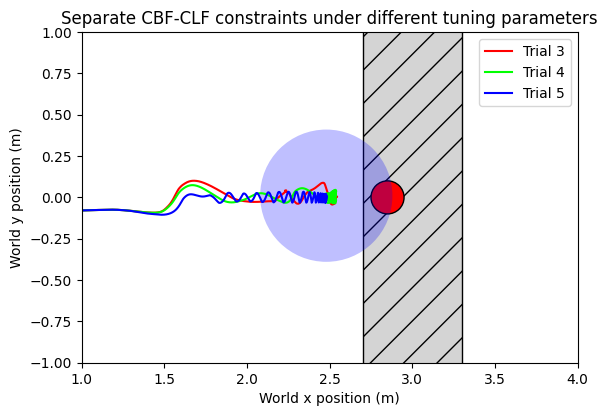

In [7]:
# Trajectory plots for tuning slack in separate CBF-CLF

data_threshold = 10000

# Load data
separated_1 = np.load("./separated_pos_1.npy")
separated_5 = np.load("./separated_pos_5.npy")
separated_6 = np.load("./separated_pos_6.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.85, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_separated_1 = Circle((separated_1[data_threshold-1,:2]), radius=0.4, facecolor=(0,0,1.0,0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_separated_1)

ax.plot(separated_5[:data_threshold,0], separated_5[:data_threshold,1], color=(1.0,0,0), label="Trial 3")
ax.plot(separated_6[:data_threshold,0], separated_6[:data_threshold,1], color=(0,1.0,0), label="Trial 4")
ax.plot(separated_1[:data_threshold,0], separated_1[:data_threshold,1], color=(0,0,1.0), label="Trial 5")
ax.set_xlim(1, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Separate CBF-CLF constraints under different tuning parameters')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend()
plt.show()

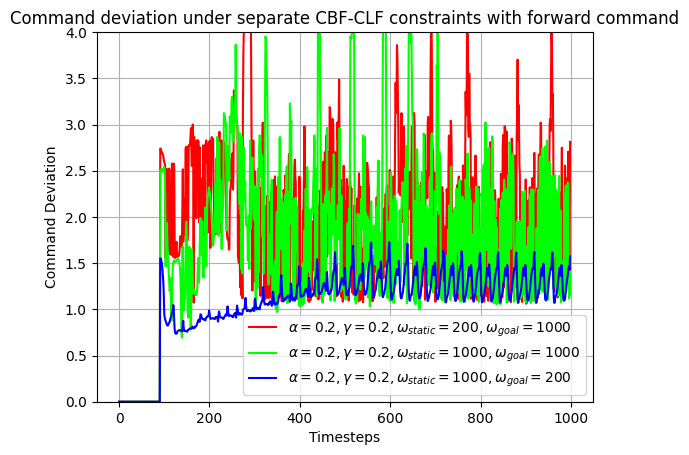

Consecutive command deviation 5
0.8224060060060059
1.2530036366896633
Consecutive command deviation 6
0.6060604604604605
1.0652043157077382
Consecutive command deviation 1
0.008777077077077077
0.049500808024315376


In [8]:
# Consecutive command error for tuning slack weight for separate CBF_CLF

# Load data
separated_cmds_1 = np.load("./separated_cmds_1.npy")
separated_cmds_5 = np.load("./separated_cmds_5.npy")
separated_cmds_6 = np.load("./separated_cmds_6.npy")

def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(separated_cmds_5,axis=0)), command_change(separated_cmds_5), color=(1.0,0,0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=200, \omega_{goal}=1000$")
ax.plot(range(np.size(separated_cmds_6,axis=0)), command_change(separated_cmds_6), color=(0,1.0,0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=1000$")
ax.plot(range(np.size(separated_cmds_1,axis=0)), command_change(separated_cmds_1), color=(0,0,1.0), label=r"$\alpha=0.2,\gamma=0.2, \omega_{static}=1000, \omega_{goal}=200$")
ax.set_ylim(0, 4.0)
plt.title('Command deviation under separate CBF-CLF constraints with forward command')
plt.xlabel("Timesteps")
plt.ylabel("Command Deviation")
plt.grid(True)
plt.legend()
plt.show()

def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

separated_change_5 = consecutive_change(separated_cmds_5)
print("Consecutive command deviation 5")
print(np.mean(separated_change_5))
print(np.std(separated_change_5))
separated_change_6 = consecutive_change(separated_cmds_6)
print("Consecutive command deviation 6")
print(np.mean(separated_change_6))
print(np.std(separated_change_6))
separated_change_1 = consecutive_change(separated_cmds_1)
print("Consecutive command deviation 1")
print(np.mean(separated_change_1))
print(np.std(separated_change_1))



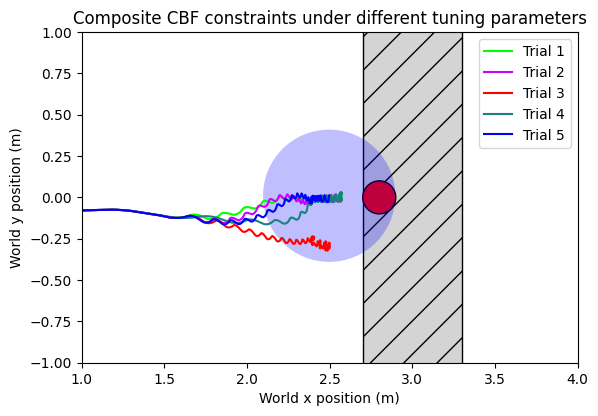

In [9]:
# Trajectory plots for tuning slack in composite CBF

data_threshold = 10000

# Load data
composite_1 = np.load("./composite_pos_1.npy")
composite_2 = np.load("./composite_pos_2.npy")
composite_3 = np.load("./composite_pos_3.npy")
composite_4 = np.load("./composite_pos_4.npy")
composite_5 = np.load("./composite_pos_5.npy")
composite_6 = np.load("./composite_pos_6.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
circle_separated_1 = Circle((composite_3[data_threshold-1,:2]), radius=0.4, facecolor=(0,0,1.0,0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_separated_1)

ax.plot(composite_4[:data_threshold,0], composite_4[:data_threshold,1], color=(0,1.0,0), label="Trial 1")
ax.plot(composite_5[:data_threshold,0], composite_5[:data_threshold,1], color=(0.8,0.0,1.0), label="Trial 2")
ax.plot(composite_2[:data_threshold,0], composite_2[:data_threshold,1], color=(1.0,0,0), label="Trial 3")
ax.plot(composite_6[:data_threshold,0], composite_6[:data_threshold,1], color=(0.1,0.5,0.5), label="Trial 4")
ax.plot(composite_3[:data_threshold,0], composite_3[:data_threshold,1], color=(0,0.0,1.0), label="Trial 5")
ax.set_xlim(1, 4)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Composite CBF constraints under different tuning parameters')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend()
plt.show()

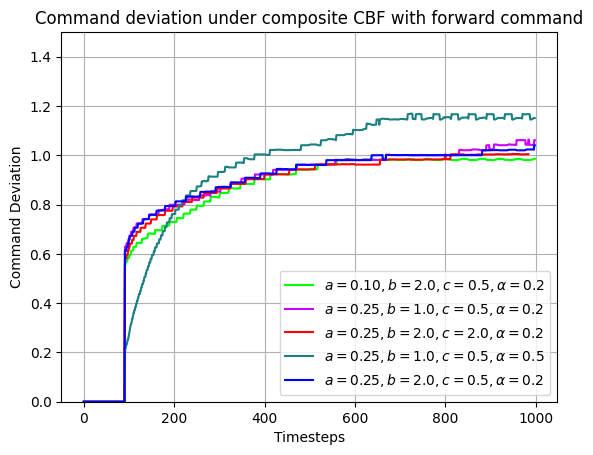

Consecutive command deviation 2
0.0005848730964467004
0.018040747016204103
Consecutive command deviation 3
0.0006333333333333334
0.019406347062399618
Consecutive command deviation 4
0.0006193193193193194
0.017542480889911494
Consecutive command deviation 5
0.0006643643643643644
0.019892896186580314
Consecutive command deviation 6
0.00025965965965965955
0.006456364993803981


In [10]:
# Consecutive command error for tuning slack weight for composite CBF

# Load data
composite_cmds_2 = np.load("./composite_cmds_2.npy")
composite_cmds_3 = np.load("./composite_cmds_3.npy")
composite_cmds_4 = np.load("./composite_cmds_4.npy")
composite_cmds_5 = np.load("./composite_cmds_5.npy")
composite_cmds_6 = np.load("./composite_cmds_6.npy")


def command_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            original_cmd = [1.0, 0.0, 0.0]
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - original_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

fig, ax = plt.subplots()

ax.plot(range(np.size(composite_cmds_4,axis=0)), command_change(composite_cmds_4), color=(0,1.0,0), label=r"$a=0.10, b=2.0, c=0.5, \alpha=0.2$")
ax.plot(range(np.size(composite_cmds_5,axis=0)), command_change(composite_cmds_5), color=(0.8,0.0,1.0), label=r"$a=0.25, b=1.0, c=0.5, \alpha=0.2$")
ax.plot(range(np.size(composite_cmds_2,axis=0)), command_change(composite_cmds_2), color=(1.0,0,0), label=r"$a=0.25, b=2.0, c=2.0, \alpha=0.2$")
ax.plot(range(np.size(composite_cmds_6,axis=0)), command_change(composite_cmds_6), color=(0.1,0.5,0.5), label=r"$a=0.25, b=1.0, c=0.5, \alpha=0.5$")
ax.plot(range(np.size(composite_cmds_3,axis=0)), command_change(composite_cmds_3), color=(0,0.0,1.0), label=r"$a=0.25, b=2.0, c=0.5, \alpha=0.2$")
ax.set_ylim(0, 1.5)
plt.title('Command deviation under composite CBF with forward command')
plt.xlabel("Timesteps")
plt.ylabel("Command Deviation")
plt.grid(True)
plt.legend()
plt.show()

def consecutive_change(cmd_array):
    change = []
    for i in range(np.size(cmd_array,axis=0)):
        if i != 0:
            prev_cmd = cmd_array[i-1]
            curr_cmd = cmd_array[i]
            change.append(np.sum((curr_cmd - prev_cmd)**2))
        else:
            change.append(0)
    return np.array(change)

composite_change_2 = consecutive_change(composite_cmds_2)
print("Consecutive command deviation 2")
print(np.mean(composite_change_2))
print(np.std(composite_change_2))
composite_change_3 = consecutive_change(composite_cmds_3)
print("Consecutive command deviation 3")
print(np.mean(composite_change_3))
print(np.std(composite_change_3))
composite_change_4 = consecutive_change(composite_cmds_4)
print("Consecutive command deviation 4")
print(np.mean(composite_change_4))
print(np.std(composite_change_4))
composite_change_5 = consecutive_change(composite_cmds_5)
print("Consecutive command deviation 5")
print(np.mean(composite_change_5))
print(np.std(composite_change_5))
composite_change_6 = consecutive_change(composite_cmds_6)
print("Consecutive command deviation 6")
print(np.mean(composite_change_6))
print(np.std(composite_change_6))


### Scenario 2: Pure Obstacle

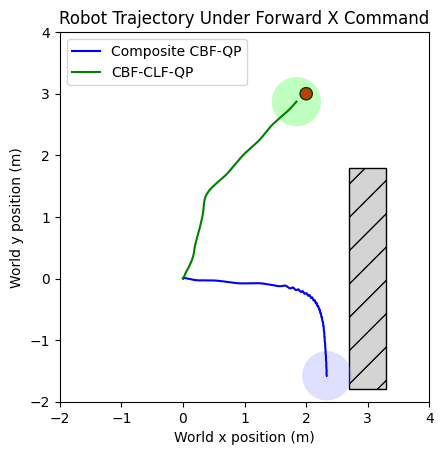

In [30]:
# Trajectory plots for obstacle

data_threshold = 10000
data_threshold_2 = 2000

composite = np.load("./composite_pos_static_obs.npy")
separate = np.load("./separated_pos_static_obs.npy")

fig, ax = plt.subplots()

rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2, 3), radius=0.1, edgecolor="black", facecolor="red")
circle_separate = Circle((separate[data_threshold_2-1, :2]), radius=0.4, facecolor=(0.0,1.0,0.0,0.25))
circle_composite = Circle((composite[data_threshold-1, :2]), radius=0.4, facecolor=(0.5,0.5,1.0,0.25))
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.add_patch(circle_separate)
ax.add_patch(circle_composite)

ax.plot(composite[:data_threshold,0], composite[:data_threshold,1], color="b", label="Composite CBF-QP")
ax.plot(separate[:data_threshold_2,0], separate[:data_threshold_2,1], color="g", label="CBF-CLF-QP")

ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Robot Trajectory Under Forward X Command')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend()
plt.show()

### Scenario 3: Moving Obstacle

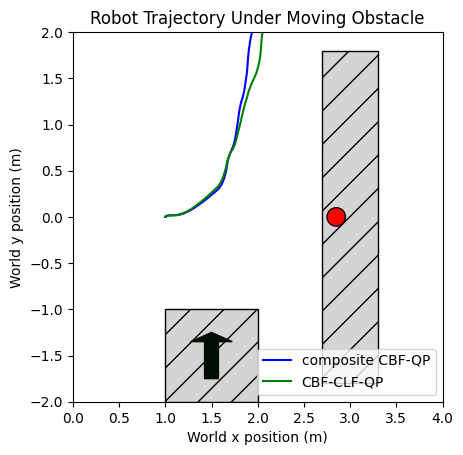

In [12]:
# Trajectory plots for obstacle

data_threshold = 2000

composite = np.load("./composite_pos_moving_obs.npy")
separate = np.load("./separated_pos_moving_obs.npy")

fig, ax = plt.subplots()

rect_obs = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
rect_moving = Rectangle((1, -2), width=1, height=1, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")
circle_target = Circle((2.85, 0), radius=0.1, edgecolor="black", facecolor="red")
circle_separate = Circle((separate[data_threshold-1, :2]), radius=0.05, facecolor="g")
circle_composite = Circle((composite[data_threshold-1, :2]), radius=0.05, facecolor="b")
arrow = Arrow(1.5, -1.75, 0, 0.5, width=0.75, color=(0.01, 0.05, 0.01))
ax.add_patch(rect_obs)
ax.add_patch(rect_moving)
ax.add_patch(circle_target)
ax.add_patch(circle_separate)
ax.add_patch(arrow)

ax.plot(composite[:data_threshold,0], composite[:data_threshold,1], color="b", label="composite CBF-QP")
ax.plot(separate[:data_threshold,0], separate[:data_threshold,1], color="g", label="CBF-CLF-QP")
ax.set_xlim(0, 4)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
plt.grid(False)
plt.title('Robot Trajectory Under Moving Obstacle')
plt.xlabel("World x position (m)")
plt.ylabel("World y position (m)")
plt.legend(loc="lower right")
plt.show()

### Contact Checking

In [13]:
contact_2 = np.load("./composite_col_2.npy")
contact_3 = np.load("./composite_col_3.npy")
contact_4 = np.load("./composite_col_4.npy")
contact_5 = np.load("./composite_col_5.npy")
contact_6 = np.load("./composite_col_6.npy")



print(contact_2)
print(contact_3)
print(max(contact_4))
print(max(contact_5))
print(max(contact_6))

[]
[]
272.4382231258059
98.06503094424855
194.26540712223428


In [14]:
separated_1 = np.load("./separated_col_1.npy")
separated_2 = np.load("./separated_col_2.npy")
separated_3 = np.load("./separated_col_3.npy")
separated_4 = np.load("./separated_col_4.npy")
separated_5 = np.load("./separated_col_5.npy")
separated_6 = np.load("./separated_col_6.npy")


print(separated_1)
print(separated_2)
print(separated_3)
print(separated_4)
print(max(separated_5))
print(max(separated_6))

[]
[]
[]
[]
255.88395119930814
221.89950680151622


## Safety Map

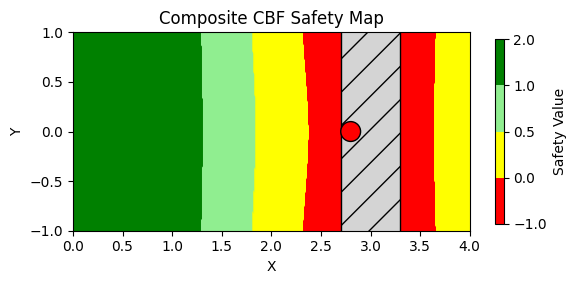

In [15]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Define thresholds and corresponding colors
bounds = [-1, 0, 0.5, 1, 2.0]
colors = ['red', 'yellow', 'lightgreen', 'green']

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

safety_map = np.load("./safety_map_comp.npy")

fig, ax = plt.subplots()
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")

safety_plot = ax.scatter(
    safety_map[:, 0],  # x
    safety_map[:, 1],  # y
    c=safety_map[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10  # dot size
)
cbar = fig.colorbar(safety_plot, ax=ax, label='Safety Value', shrink=0.5)
ax.set_xlim(0, 4)
ax.set_ylim(-1, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.add_patch(rect)
ax.add_patch(circle_target)
ax.set_aspect('equal')
plt.title("Composite CBF Safety Map")
plt.show()

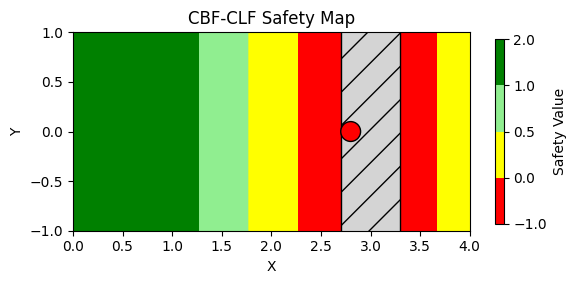

In [16]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Define thresholds and corresponding colors
bounds = [-1, 0, 0.5, 1, 2.0]  # your thresholds
colors = ['red', 'yellow', 'lightgreen', 'green']

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

safety_map = np.load("./safety_map_obs.npy")

fig, ax = plt.subplots()
circle_target = Circle((2.8, 0.0), radius=0.1, edgecolor="black", facecolor="red")
rect = Rectangle((2.7, -1.8), width=0.6, height=3.6, 
                 edgecolor='black', facecolor=(0.83, 0.83, 0.83), hatch="/")

safety_plot = ax.scatter(
    safety_map[:, 0],  # x
    safety_map[:, 1],  # y
    c=safety_map[:, 2],  # h value = color
    cmap=cmap,
    norm=norm,
    s=10  # dot size
)
cbar = fig.colorbar(safety_plot, ax=ax, label='Safety Value', shrink=0.5)
ax.set_xlim(0, 4)
ax.set_ylim(-1, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.add_patch(rect)
ax.add_patch(circle_target)
plt.title("CBF-CLF Safety Map")
ax.set_aspect('equal')
plt.show()